# Clase Auxiliar: Escalado, PCA y Clustering

En esta actividad aplicaremos un flujo típico de análisis no supervisado:

1. Escalado de datos
2. Reducción de dimensionalidad con PCA
3. Agrupamiento con K-means


## 1. Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## 2. Cargar y visualizar los datos


Cargamos el dataset de Iris, una muestra de flores que ya ha sido vista en clases :)

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

print("Características:", feature_names)
print("Primeras filas:\n", X[:5])

Características: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Primeras filas:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


## 3. Escalado de los datos
Usamos `StandardScaler` para que cada variable tenga media 0 y desviación estándar 1.

Escalar significa transformar los datos para que todas las variables tengan la misma importancia numérica, normalmente haciendo que cada columna tenga media 0 y desviación estándar 1.

Muchos algoritmos (como K-means y PCA) se basan en distancias. Si una variable tiene un rango mucho mayor que otra, dominará el análisis.

Un ejemplo podria ser que estás clasificando galaxias usando su masa (en $10^{11} M_\odot$) y su índice de color (valores entre -0.2 y 1.5). Si no escalas, la masa tendrá mucho más peso que el color, aunque ambos podrían ser igualmente importantes para la clasificación.


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Reducción de dimensionalidad con PCA

PCA (Análisis de Componentes Principales) encuentra nuevas variables (combinaciones lineales de las originales) que capturan la mayor parte de la varianza del conjunto de datos en menos dimensiones.

Realizamos esto para:

    - Reducir la cantidad de variables (dimensiones) manteniendo la mayor información posible.

    - Eliminar redundancia entre variables que están correlacionadas.

    - Visualizar datos en 2D o 3D, incluso si originalmente estaban en 10 dimensiones.
    
    - Preparar datos para clustering o clasificación, eliminando el “ruido” o variables menos importantes.

Imagina que tienes datos de estrellas con 10 características distintas (temperatura, gravedad superficial, metalicidad, colores, etc). Muchas de estas variables están correlacionadas y PCA encontrara esta relacion para reducir la cantidad de dimenciones del dataset.

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)

Varianza explicada por cada componente: [0.72962445 0.22850762]


## 5. Clustering con K-means


Clustering busca agrupar datos similares sin que se les diga qué clases o etiquetas tienen. En lugar de decirle al modelo “estos datos son del tipo A, estos del B”, el modelo descubre patrones por sí solo.

Esto sirve para:

    - Para descubrir grupos ocultos en los datos.

    - Para hacer análisis exploratorio antes de aplicar otros métodos.

	- Para encontrar estructuras o comportamientos comunes.

Usaremos K-means, este intenta dividir los datos en K grupos (clusters) de la siguiente manera:
	- Elige K puntos aleatorios como “centros” de los grupos.

	- Asigna cada punto del dataset al centro más cercano.

	- Calcula un nuevo centro para cada grupo.

	- Repite los pasos 2 y 3 hasta que los centros ya no cambien mucho.

Al final, tienes K grupos, cada uno con puntos que están más cerca de su propio centro que de los otros.


Supongamos que tenemos 2 variables (como las componentes principales de PCA). Si hay agrupaciones naturales, K-means puede encontrarlas.

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

## 6. Visualización de los clusters

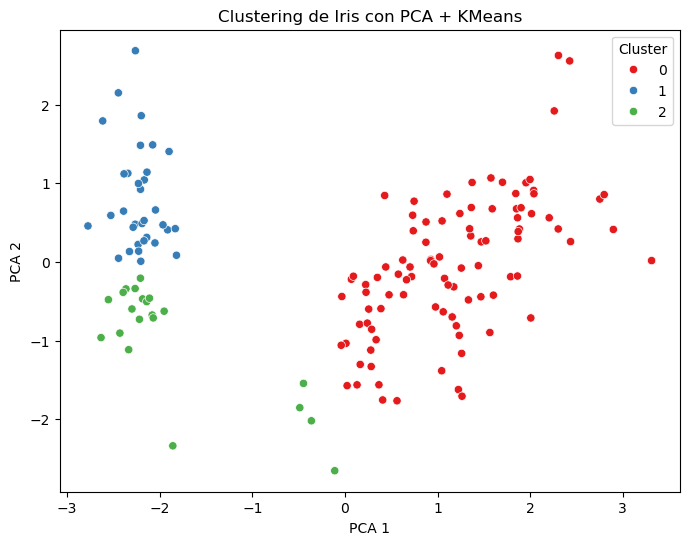

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set1')
plt.title('Clustering de Iris con PCA + KMeans')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()